# Vol-Engine (направление A) — результаты M0–M5

**Пивот C → A.** Направление C (микроструктура + тройной барьер) провалило пред-зарегистрированный
экономический гейт на де-перекрытых сделках (см. `../v2_microstructure/FINDINGS_C.md`) и ретайрнуто.
A возвращается к **предсказуемой** цели — реализованной волатильности.

**Преемственность с дипломом.** В исходном дипломе рассматривалось семейство **GARCH**. A использует
**HAR-RV** (Corsi 2009) — реализационно-волатильностного наследника GARCH — на той же волатильностной
цели, исправляя «уход в уровень цены».

**Три намеренно расцепленных слоя:**
1. **Layer 1 (гарантированный):** прогноз log-RV; HAR-семейство vs ML+exo; судья — proper
   vol-scoring (QLIKE, R²-logRV, DM(HLN)). Эконометрический результат защитим при любом исходе торговли.
2. **Layer 2 (может провалиться):** vol-timing оверлей на перпе; судья — net-cost Sharpe vs buy&hold.
3. **Layer 3 (бэклог):** DVOL / IV−RV / VRP.

> **Принцип (из C/B):** *предсказуемая цель ≠ торговый эдж.* Предсказуемость проверяется на Layer 1,
> эдж — только на Gate 2. Этот ноутбук проходит M0–M5; **оба пред-зарегистрированных гейта (Gate 1
> ML+exo, Gate 2 vol-timing) — FAIL**, и это честный, защитимый результат: тезис держится на Layer-1
> (HARQ значимо прогнозирует RV, многогоризонтно) + дисциплине kill-switch. Holdout запечатан до M6/M7.

```text
schema:  spot-OHLC 2017→ ─▶ RV (Rogers-Satchell) ─▶ HAR family vs naive  ─▶ [Gate 1: ML+exo vs HARQ @M3]
                                                  └▶ vol-timing overlay   ─▶ [Gate 2: net-cost Sharpe @M5]
```

## §1. Окружение и конфигурация
**Что:** подключаем пакет, фиксируем seed, печатаем ключевые параметры и хэш снапшота.
**Зачем:** детерминизм и воспроизводимость.

In [2]:
import sys, pathlib, json
_p = pathlib.Path.cwd().resolve()
REPO_ROOT = next((q for q in [_p, *_p.parents] if (q / "v2_volengine").is_dir()), _p)
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

import numpy as np, pandas as pd
from IPython.display import Image, display
from v2_volengine.src import (config, data_spot as dsx, rv as rvmod, har as harmod,
                              vol_evaluate as ve, plots_vol as vp)
from ml_models import set_global_seed
set_global_seed(config.SEED)

print("seed            :", config.SEED)
print("RV_ESTIMATOR    :", config.RV_ESTIMATOR, "(range method:", config.RV_RANGE_METHOD + ")")
print("target transform:", config.TARGET_TRANSFORM)
print("HAR windows     :", config.HAR_WINDOWS, "| variants:", config.HAR_VARIANTS)
print("MIN_BARS_KEEP   :", config.MIN_BARS_KEEP, "| holdout cut:", config.HOLDOUT_CUT)
print("WF splits       :", config.WF_N_SPLITS)
spot_manifest = json.loads(config.SPOT_MANIFEST.read_text())
print("spot snapshot sha:", spot_manifest["content_sha256"][:12])

/Users/tigran/python_projects_epta/personal_projects/diploma/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


seed            : 42
RV_ESTIMATOR    : range (range method: rogers_satchell)
target transform: log
HAR windows     : (1, 5, 22) | variants: ('HAR', 'HARJ', 'HARQ')
MIN_BARS_KEEP   : 12 | holdout cut: 2025-06-01
WF splits       : 5
spot snapshot sha: a76714d9d9d5


## §2. Данные: замороженный spot-OHLC снапшот + аудит баров (R4)
**Что:** читаем замороженный длинный spot-снапшот (только эта ячейка использовала сеть при сборке).
**На что смотреть:** покрытие 2017-08→2026-06, короткие дни (1 severe дропнут, 29 mild масштабированы).

coverage: 2017-08-17 04:00:00 → 2026-06-18 23:00:00 | bars: 77340
bars/day: full=3198  short=30  (frac_full=0.9907)  min=1 max=24
severe days (< 12 bars, DROPPED): 1 | mild short (scaled): 29


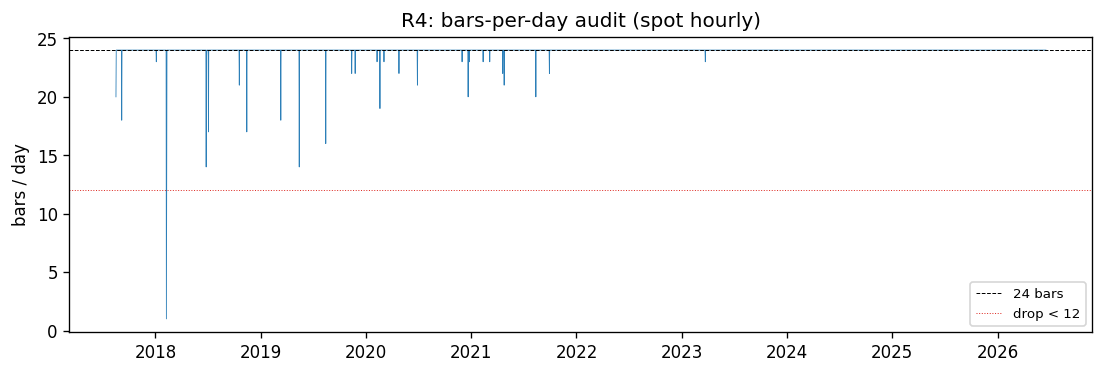

In [3]:
spot = dsx.load_spot_snapshot()
audit = dsx.audit_bars_per_day(spot)
print("coverage:", spot.index.min(), "→", spot.index.max(), "| bars:", len(spot))
print("bars/day: full=%d  short=%d  (frac_full=%.4f)  min=%d max=%d"
      % (audit["full_days"], audit["short_days"], audit["frac_full"], audit["min_bars"], audit["max_bars"]))
severe = (spot.groupby(spot.index.normalize()).size() < config.MIN_BARS_KEEP).sum()
print("severe days (< %d bars, DROPPED): %d | mild short (scaled): %d"
      % (config.MIN_BARS_KEEP, severe, audit["short_days"] - severe))
display(Image(str(vp.plot_bars_per_day(spot))))

In [4]:
spot

,open,high,low,close,volume
timestamp,,,,,
2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807
...,...,...,...,...,...
2026-06-18 19:00:00,62708.93,63008.33,62636.00,62950.79,577.637640
2026-06-18 20:00:00,62950.79,63274.19,62950.79,63086.00,684.934290
2026-06-18 21:00:00,63086.00,63121.81,62870.39,62971.32,466.341720


In [5]:
audit

{'n_days': 3228,
 'full_days': 3198,
 'short_days': 30,
 'over_days': 0,
 'min_bars': 1,
 'max_bars': 24,
 'median_bars': 24.0,
 'first_short_days': ['2017-08-17',
  '2017-09-06',
  '2018-01-04',
  '2018-02-08',
  '2018-02-09',
  '2018-06-26',
  '2018-06-27',
  '2018-07-04',
  '2018-10-19',
  '2018-11-14'],
 'frac_full': 0.9907063197026023}

## §3. Построение RV + персистентность
**Что:** строим дневной RV (Rogers-Satchell — primary, close — robustness) из `rv.py`.
**На что смотреть:** аннуализированная вола; **ACF log-RV** — ключевой визуал предсказуемости
(длинная память: ~0.75 range / 0.64 close).

range : days=3227  logRV ACF1=0.750  jump_frac=0.174  short_frac=0.0090
close : days=3227  logRV ACF1=0.637  jump_frac=0.176  short_frac=0.0090
median annualised vol (range): 0.531


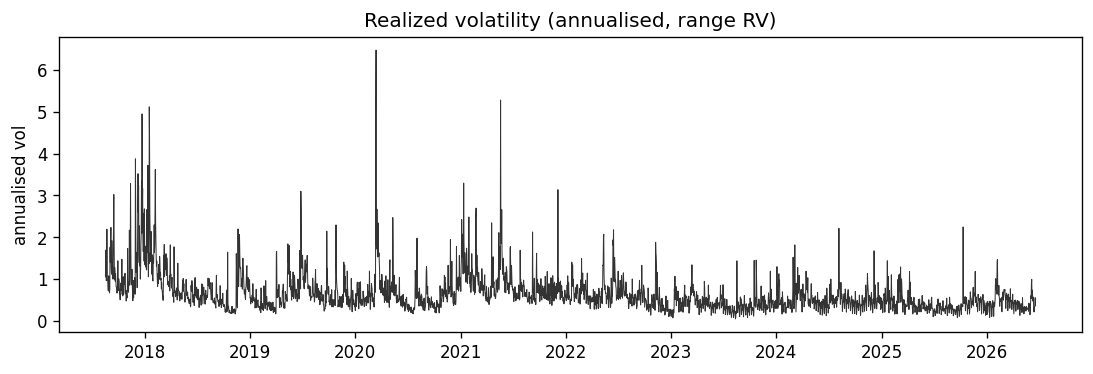

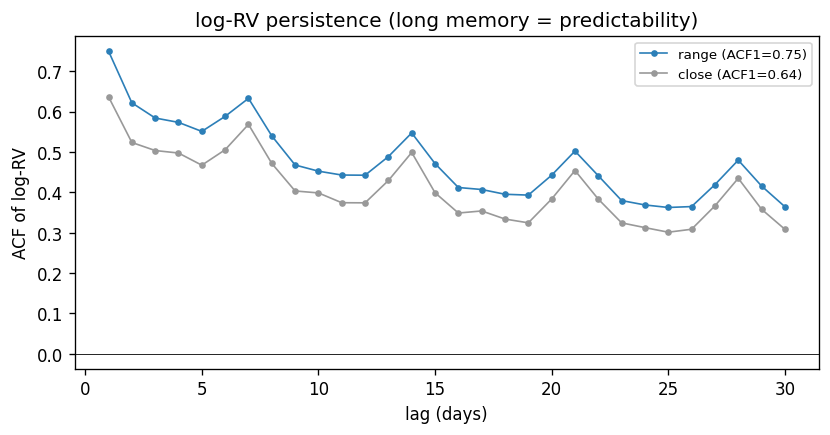

In [7]:
frames = {est: rvmod.build_rv(spot, estimator=est) for est in ("range", "close")}
for est, fr in frames.items():
    rep = rvmod.rv_report(fr)
    print(f"{est:6s}: days={rep['n_days']}  logRV ACF1={rep['logRV_acf1']:.3f}  "
          f"jump_frac={rep['jump_frac_of_rv']:.3f}  short_frac={rep['short_day_frac']:.4f}")
ann_med = float((np.sqrt(frames['range']['rv']) * np.sqrt(config.DAYS_PER_YEAR)).median())
print("median annualised vol (range):", round(ann_med, 3))
display(Image(str(vp.plot_rv_timeseries(frames['range']))))
display(Image(str(vp.plot_logrv_acf(frames))))

## §4. Ошибка измерения и выбор оценщика RV (model-free)
**Что:** сравниваем fidelity hourly close-RV и Rogers-Satchell-RV к 5-min RV на ~2-мес окне.
**Решение (пред-зарегистрировано):** оценщик с лучшей fidelity → `RV_ESTIMATOR`. Решаем по точности
измерения, НЕ по forecast-R² (иначе forking). Честно: hourly RV грубее 5-min.

In [8]:
try:
    fid = rvmod.estimator_fidelity_5min("2026-03-01", "2026-06-15", hourly_spot=spot)
    print("5-min fidelity (full days =", fid["n_full_days"], ", reference = 5min close-RV):")
    print("  close (Σ Δlogc²)   : corr=%.3f  rmse=%.3f" % (fid["close"]["logrv_corr"], fid["close"]["logrv_rmse"]))
    print("  Rogers-Satchell    : corr=%.3f  rmse=%.3f" % (fid["range_rogers_satchell"]["logrv_corr"], fid["range_rogers_satchell"]["logrv_rmse"]))
    print("  WINNER:", fid["winner"], "→ RV_ESTIMATOR =", config.RV_ESTIMATOR)
except Exception as e:
    print("fidelity test requires network; recorded result: range wins (RS corr 0.980/rmse 0.161 vs close 0.921/0.393)")
    print("error:", type(e).__name__)

5-min fidelity (full days = 106 , reference = 5min close-RV):
  close (Σ Δlogc²)   : corr=0.921  rmse=0.393
  Rogers-Satchell    : corr=0.980  rmse=0.161
  WINNER: range → RV_ESTIMATOR = range


In [9]:
fid

{'n_full_days': 106,
 'reference': '5min_close_rv',
 'close': {'logrv_corr': 0.9210604704343128,
  'logrv_rmse': 0.39251819062117443},
 'range_rogers_satchell': {'logrv_corr': 0.9804738104609684,
  'logrv_rmse': 0.16099776529587426},
 'winner': 'range'}

## §5. HAR-семейство vs naive — гарантированный результат Layer-1
**Что:** OOF HAR/HARQ/HARJ + naive RW/AR1/MEAN; QLIKE (variance scale, lognormal-correction) +
R²-logRV; **Diebold-Mariano(HLN)** значимость — сперва на 1-day-ahead (h=1), затем многогоризонтно
(средний RV на [t+1, t+h], h∈{1,5,22}). **Дисциплина MASE:** HAR обязан out-predict наивную
персистентность, иначе это «персистентность под видом skill».


=== h=1 (logRV_{t+1}) — RV estimator: range (OOF days=1410) ===
model  QLIKE  R2_logRV  DM_vs_RW_stat  DM_vs_RW_p  DM_vs_AR1_stat  DM_vs_AR1_p  QLIKE_vs_RW_pct
 HARQ 0.3460    0.4038        -6.1951         0.0         -0.4079       0.6834          21.0905
 HARJ 0.3475    0.4023        -6.1900         0.0         -0.2927       0.7698          20.7566
  HAR 0.3482    0.4008        -6.3194         0.0         -0.2453       0.8062          20.6000
  AR1 0.3515    0.3368        -5.5046         0.0             NaN          NaN          19.8439
   RW 0.4385    0.2316            NaN         NaN             NaN          NaN           0.0000
 MEAN 0.7092   -0.3446         5.8797         0.0          9.5281       0.0000         -61.7399

=== h=1 (logRV_{t+1}) — RV estimator: close (OOF days=1410) ===
model  QLIKE  R2_logRV  DM_vs_RW_stat  DM_vs_RW_p  DM_vs_AR1_stat  DM_vs_AR1_p  QLIKE_vs_RW_pct
 HARQ 0.4492    0.2896        -7.8342         0.0         -1.5726       0.1160          27.6225
  HAR 

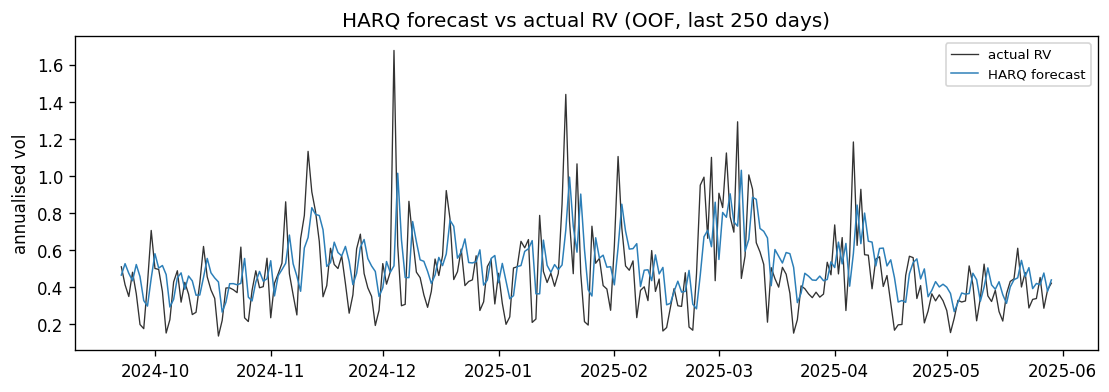

In [5]:
tables, mh = {}, {}
for est in ("range", "close"):
    dev, _ = rvmod.seal_holdout(frames[est].index)
    fdev = frames[est][dev.to_numpy()]
    oof = harmod.walk_forward_oof(fdev, embargo=5)                          # h=1 detail (per model)
    tables[est] = (oof, ve.summarize_models(oof))
    mh[est] = ve.multi_horizon_summary(fdev, horizons=config.HAR_HORIZONS, embargo=5)
for est, (oof, tbl) in tables.items():
    print(f"\n=== h=1 (logRV_{{t+1}}) — RV estimator: {est} (OOF days={len(oof)}) ===")
    print(tbl.round(4).to_string(index=False))
display(Image(str(vp.plot_har_vs_actual(tables['range'][0], 'HARQ'))))

### §5.1 Многогоризонтный HAR — прямой прогноз среднего RV на [t+1, t+h]
**Что:** стандартная многогоризонтная оценка HAR (Corsi, direct): цель — **средний** дневной RV на
горизонте h∈{1,5,22}; на каждом h — свой horizon-aware Diebold-Mariano(HLN) (потери h-шагового прогноза
автокоррелированы как MA(h−1); train/test-зазор = embargo+(h−1) — гэп чистит перекрытие h-дневной метки).
**Пред-зарегистрированное ожидание (не подгонка):** преимущество HAR над **AR(1)** незначимо при h=1 и
должно усиливаться при h=5, 22 — длинная память важнее для накопленного пути, чем для одного дня вперёд.

> **Замечание (QLIKE не сопоставим МЕЖДУ горизонтами):** на каждом h таргет — средний RV на своём
> отрезке (разный масштаб и дисперсия), поэтому QLIKE сравнивают только между моделями **внутри** одного
> h. Падение абсолютного QLIKE с ростом h ≠ «прогноз точнее» — у среднего RV на длинном окне меньше
> дисперсия. Содержательный тест — относительные DM-сравнения (vs RW / vs AR1) внутри каждого h.

In [6]:
cols = ["horizon", "model", "QLIKE", "R2_logRV",
        "DM_vs_RW_stat", "DM_vs_RW_p", "DM_vs_AR1_stat", "DM_vs_AR1_p"]
for est in ("range", "close"):
    print(f"\n=== Multi-horizon HAR vs naive (mean RV over [t+1,t+h]) — RV estimator: {est} ===")
    print(mh[est][cols].round(4).to_string(index=False))


=== Multi-horizon HAR vs naive (mean RV over [t+1,t+h]) — RV estimator: range ===
 horizon model  QLIKE  R2_logRV  DM_vs_RW_stat  DM_vs_RW_p  DM_vs_AR1_stat  DM_vs_AR1_p
       1  HARQ 0.3460    0.4038        -6.1951      0.0000         -0.4079       0.6834
       1  HARJ 0.3475    0.4023        -6.1900      0.0000         -0.2927       0.7698
       1   HAR 0.3482    0.4008        -6.3194      0.0000         -0.2453       0.8062
       1   AR1 0.3515    0.3368        -5.5046      0.0000             NaN          NaN
       1    RW 0.4385    0.2316            NaN         NaN             NaN          NaN
       1  MEAN 0.7092   -0.3446         5.8797      0.0000          9.5281       0.0000
       5  HARQ 0.2411    0.3307        -3.4482      0.0006         -7.3082       0.0000
       5  HARJ 0.2430    0.3262        -3.4526      0.0006         -6.9930       0.0000
       5   HAR 0.2448    0.3215        -3.4514      0.0006         -6.7381       0.0000
       5   AR1 0.3063    0.0653      

**Вердикт Layer-1.** HARQ — лучший на обоих оценщиках; **HAR(Q) значимо бьёт naive RW** на всех
горизонтах (DM(HLN) p ≪ 0.01, stat < 0) — гарантированный эконометрический результат.

**Разрешение нюанса про AR(1) (многогоризонтно).** При **h=1** преимущество HAR(Q) над **AR(1)** по
точечному QLIKE есть, но **не значимо** (DM p≈0.68 range / 0.12 close) — вклад длинной памяти сверх
вчерашней волы на один день вперёд скромен. При **h=5 и h=22** превосходство над AR(1) становится
**сильно значимым** (DM stat ≈ −7…−9, p ≈ 0): недельная/месячная память HAR важна именно для прогноза
накопленной волатильности на горизонте. Это стандартное поведение HAR — расхождение при h=1 не дефект,
а ожидаемый результат, разрешённый многогоризонтной оценкой (ожидание было пред-зарегистрировано).

*(Замечание: при больших h naive RW как прогноз среднего RV резко деградирует — поэтому «% к RW»
раздувается; содержательный тест — против AR(1), и именно он усиливается с ростом h.)*

## §6. Честные ограничения
- **HARQ vs обычный HAR — в пределах шума.** Поправка на realized quarticity даёт чуть лучший точечный
  QLIKE, но превосходство HARQ над простым HAR **отдельно не значимо** (ΔQLIKE крошечный). HARQ держим
  центральным из-за шумного hourly-RV (R2), а не как доказанно лучший вариант.
- **R² ниже литературных ~0.5** — там RV на 5-min; здесь hourly-RV (грубее; range частично лечит, R2).
- **Окно 5-min fidelity (§4) пересекается с holdout-периодом**, НО выбор оценщика RV сделан по точности
  измерения (corr/RMSE к 5-min RV) — это **model-free, measurement-based** решение, не использующее
  прогнозную метрику и не настраиваемое на forecast-perf → **утечки в прогноз нет** (измерительное, а не
  модельное решение; holdout как тест прогноза остаётся нетронутым).
- **Эффективная выборка — режимы, не дни:** независимых вол-циклов (бык/медведь/кризис) в ~8 годах
  мало → широкие CI у любого торгового эджа.
- **Торговый слой (Gate 2) ещё НЕ тестирован** → предсказуемость RV пока НЕ является эджем. Это будет
  решено на M5 (vol-timing net-cost Sharpe vs buy&hold), отдельным пред-зарегистрированным гейтом.

## §8. M2 — ML+exo матрица + leakage-tripwires (перп-эра 2019→)
**Что:** строим ML+exo матрицу (HAR-компоненты + RQ/jumps/signed-RV + exo flow funding/basis/on-chain
из C-снапшота, lag t−1) на перп-эре 2019→; train-only кластеризация коллинеарности + stable-select;
прогоняем leakage-tripwires как **hard gate** (assert all green). **На что смотреть:** границы
gate-выборки (2089 dev-строк — общие для обоих плеч M3), отобранные фичи, и все tripwires GREEN.

In [7]:
from v2_volengine.src import experiment_vol as ex
res2 = ex.run_m2_features()                # builds matrix, train-only select, asserts tripwires GREEN
print("\nselected features:", res2["selected"])

run_id=run_20260619T022346Z
gate subsample (perp-era dev): 2019-09-12 00:00:00 → 2025-05-31 00:00:00 | rows=2089
candidates (19): ['har_d', 'har_w', 'har_m', 'rq_term', 'jump_d', 'signed_rv', 'bpv_ratio', 'funding', 'funding_chg', 'basis', 'basis_chg', 'tfi', 'cvd', 'vpin', 'active_addr_chg', 'tx_cnt_chg', 'addr_bal_chg', 'hashrate_chg', 'supply_chg']
collinear clusters: none
selected (10): ['har_d', 'har_w', 'har_m', 'tx_cnt_chg', 'bpv_ratio', 'vpin', 'signed_rv', 'addr_bal_chg', 'cvd', 'supply_chg']
tripwires:
   {'check': 'label_shuffle_reg', 'passed': True, 'shuffled_r2': -0.09057831966204466, 'tol': 0.05, 'note': 'leak == shuffled R² > tol; negative R² = no signal (pass)'}
   {'check': 't_minus_1_availability', 'passed': True, 'flagged': {}, 'corr_threshold': 0.999}
   {'check': 'bars_per_day', 'passed': True, 'frac_full': 0.9907063197026023, 'short_days': 30, 'min_bars': 1}
   {'check': 'feature_dominance', 'passed': True, 'top_feature': 'tx_cnt_chg', 'share': 0.11987733482018399

## §9. M3 — Gate 1: ML+exo vs HARQ (forecasting kill-switch)
**Что:** лестница **HARQ → Ridge(HAR+exo) → LightGBM** на gate-выборке 2019→ (оба плеча — одни строки).
QLIKE + R²-logRV + **Diebold-Mariano(HLN)** vs HARQ (headline WF-OOF), затем дистрибутивный CPCV-гейт
(DM-значимость на большинстве из 15 путей + paired-bootstrap Δ-CI). Прогноз санитизирован (clip) —
единообразно для всех плеч. **Ожидание (честно):** exo/нелинейность вряд ли значимо побьют HARQ
(согласуется с M2: funding/basis не в топ-10, и с находкой C). **Вердикт — что покажет гейт.**

In [8]:
res3 = ex.run_m3_gate1()                   # ladder (WF-OOF) + Gate 1 distributional over CPCV
display(res3["ladder"].round(4))
print("Gate 1 verdict:", "PASS — ML adds value" if res3["any_pass"]
      else "FAIL — ML null, HARQ stands (Layer-1 deliverable)")

run_id=run_20260619T022351Z
gate subsample (perp-era dev): 2019-09-12 00:00:00 → 2025-05-31 00:00:00 | dev_rows=2089 oof_rows=1045 cpcv_paths=15
HARQ baseline: ['har_d', 'har_w', 'har_m', 'rq_term']
ML candidate features (19): ['har_d', 'har_w', 'har_m', 'rq_term', 'jump_d', 'signed_rv', 'bpv_ratio', 'funding', 'funding_chg', 'basis', 'basis_chg', 'tfi', 'cvd', 'vpin', 'active_addr_chg', 'tx_cnt_chg', 'addr_bal_chg', 'hashrate_chg', 'supply_chg']
QUICK_MODE=True (lgbm n_est=120, n_boot=2000)

=== M3 ladder (WF-OOF) — QLIKE / R²-logRV / DM(HLN) vs HARQ ===
  arm  QLIKE  R2_logRV  DM_vs_base_stat  DM_vs_base_p  QLIKE_vs_base_pct
 HARQ 0.3744    0.3031              NaN           NaN             0.0000
Ridge 0.3678    0.3125          -1.2154        0.2245             1.7463
 LGBM 0.3702    0.2867          -0.4647        0.6422             1.1072

=== Gate 1 (forecasting) — distributional over CPCV ===
  [Ridge vs HARQ] majority_DM_sig=0.00 majority_QLIKE_win=0.40 ΔQLIKE_mean=-0.48558 Δ-CI=

,arm,QLIKE,R2_logRV,DM_vs_base_stat,DM_vs_base_p,QLIKE_vs_base_pct
0,HARQ,0.3744,0.3031,NaN,NaN,0.0000
1,Ridge,0.3678,0.3125,-1.2154,0.2245,1.7463
2,LGBM,0.3702,0.2867,-0.4647,0.6422,1.1072


Gate 1 verdict: FAIL — ML null, HARQ stands (Layer-1 deliverable)


## §10. M4–M5 — Layer-2 vol-timing + Gate 2 (economic kill-switch)
**Что:** обратный-вол сайзинг на **HARQ-прогнозе** — `position = min(cap, target_vol/forecast_vol)`,
long-flat ∈ [0,1], cap=1 (без плеча), daily rebalance, через legacy `simulate_strategy` + funding-carry.
Судья — **net-cost Sharpe vs buy&hold** дистрибутивно по CPCV (majority + paired-bootstrap Δ-CI), плюс
PSR/DSR/PBO и breakeven-cost sweep. **Честно:** long-flat-0..1 только **de-risk**-ит (никогда не плечует)
→ тест на улучшение risk-adjusted return; OOS vol-timing спорен (Moreira–Muir 2017 vs Cederburg 2020).
`target_vol_ann` пред-зарегистрирован (M0), НЕ тюнится. Dev-период (perp-эра → 2025-05); holdout запечатан.

run_id=run_20260619T022402Z
dev (perp-era, holdout sealed): 2021-03-02 00:00:00 → 2025-05-30 00:00:00 | days=1551
target_vol_ann=0.6 cap=1.0 avg_exposure=0.902 | baseline_rt=14.0bps

=== M4 vol-timing vs buy&hold (full-sample, annualised) ===
  Sharpe   vol-timing=0.347  buy&hold=0.600  const-vol=0.600
  MaxDD    vol-timing=0.768  buy&hold=0.767

=== M5 Gate 2 (economics) — distributional over CPCV ===
  majority(vt>bh)=0.00 (thr 0.5) | ΔSharpe_mean=-0.272 Δ-CI=[-0.337,-0.219]
  PSR(vt>bh)=0.301  DSR=0.677 (≥0.95?)  PBO=0.232 (≤0.5?)  breakeven=0bps

=== A-M5 Gate 2: FAIL — vol-timing does NOT beat buy&hold — trading layer null, thesis rests on Layer-1 ===
figure: /Users/tigran/python_projects_epta/personal_projects/diploma/v2_volengine/figures/m5_vol_timing_equity.png
artifacts: /Users/tigran/python_projects_epta/personal_projects/diploma/v2_volengine/reports/run_20260619T022402Z


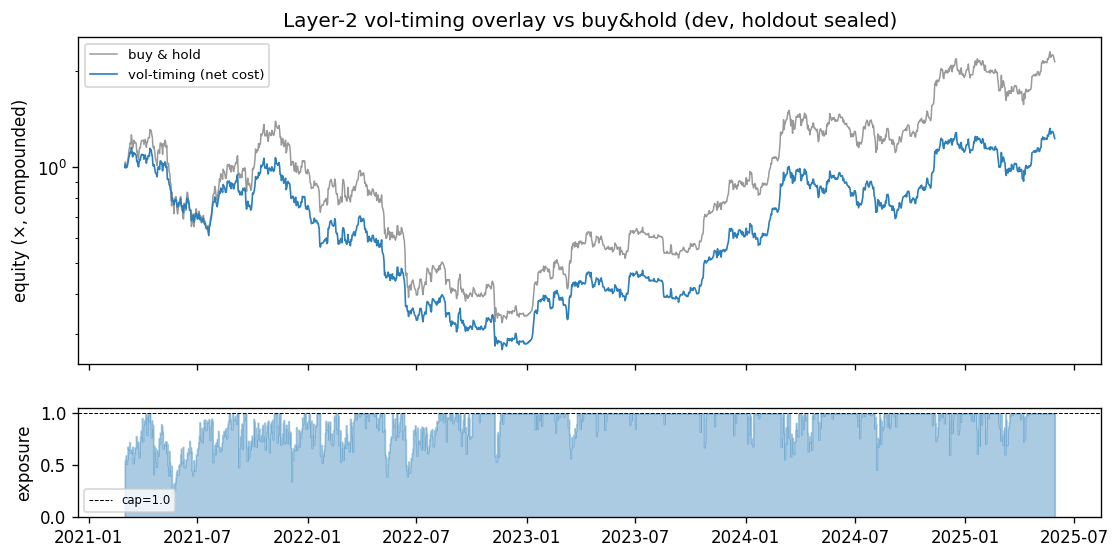


Gate 2: vol-timing Sharpe=0.347 vs buy&hold=0.600 | CPCV majority(vt>bh)=0.00 | DSR=0.677 PBO=0.232 | breakeven=0bps
Gate 2 verdict: FAIL — trading layer null, thesis rests on Layer-1


In [9]:
res45 = ex.run_m45_voltiming()             # overlay on HARQ forecast + Gate 2 economics
display(Image(str(config.FIGURES_DIR / "m5_vol_timing_equity.png")))
g = res45["gate2"]
print(f"\nGate 2: vol-timing Sharpe={g['sharpe_vol_timing']:.3f} vs buy&hold={g['sharpe_buy_hold']:.3f} "
      f"| CPCV majority(vt>bh)={g['cpcv_majority_vt_gt_bh']:.2f} | DSR={g['deflated_sharpe']:.3f} "
      f"PBO={g['pbo']:.3f} | breakeven={g['breakeven_rt_bps']:.0f}bps")
print("Gate 2 verdict:", "PASS" if g["passed"] else "FAIL — trading layer null, thesis rests on Layer-1")

## §11. Итог M0–M5 + sealed holdout (вскрытие = M6/M7)
**Тезис стоит на Layer-1 + дисциплине двух пред-зарегистрированных kill-switch:**
- **Layer-1 (деливерабл):** HARQ значимо прогнозирует RV — бьёт naive RW на всех горизонтах (DM p≪0.01),
  а над AR(1) — значимо на h=5/22 (многогоризонтное разрешение). Эконометрический результат состоятелен.
- **Gate 1 (forecasting) — FAIL:** ML+exo (Ridge/LightGBM) НЕ бьёт HARQ значимо (DM, CPCV-majority=0).
  Честный негатив: exo flow + нелинейность не добавляют прогнозной ценности над HARQ на дневном горизонте.
- **Gate 2 (economics) — FAIL:** vol-timing оверлей НЕ бьёт buy&hold по net-cost Sharpe (дистрибутивно,
  DSR<0.95). Long-flat de-risking жертвует доходностью в трендовом BTC — спорность OOS vol-timing
  (Moreira–Muir vs Cederburg) подтверждается. Торговый слой нулевой.

Ценность работы — не «нашли альфу», а **методология**: расцепленные слои + proper-scoring + пред-
регистрация + kill-switch ловят иллюзии (как спурный pass у C на перекрытых ретёрнах) до деплоя.

**Holdout (2025-06-01→) запечатан** и НЕ использовался ни в одном гейте/выборе. Вскрытие — один раз на
M6/M7 (deploy-правило DSR≥0.95 & PBO≤0.5 для торгового слоя). Ниже — guarded-заглушка.

In [10]:
UNSEAL_HOLDOUT = False     # M6/M7 ONLY — holdout stays sealed through M5
if UNSEAL_HOLDOUT:
    raise NotImplementedError("holdout unseal is M6/M7, not part of the M0–M5 notebook")
print(f"Holdout SEALED ({config.HOLDOUT_CUT}→). Не использован ни в одном гейте. Вскрытие = M6/M7.")

Holdout SEALED (2025-06-01→). Не использован ни в одном гейте. Вскрытие = M6/M7.
